# Librerias

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re 

from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer, MaxAbsScaler

from scipy import sparse as sp

from typing import Optional, List
from IPython.display import HTML, display

from pygments import highlight
from pygments.lexers import get_lexer_by_name, guess_lexer
from pygments.formatters import HtmlFormatter
from pygments.util import ClassNotFound

# Estilo

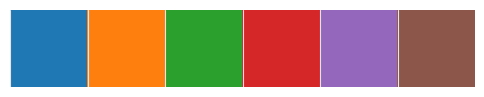

In [2]:
def apply_presentation_theme(font_family='DejaVu Sans', base_size=15, palette=None, grid=True, dpi=100):
    """
    Aplica un tema pensado para presentaciones:
      - base_size: tamaño de fuente base (ajusta todos los demás tamaños)
      - palette: lista de colores hex o nombre de paleta seaborn
      - grid: si True usa grid sutil
      - dpi: resolución de las figuras
    """
    if palette is None:
        # colores contrastantes y claros sobre fondo blanco
        palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

    sns.set_theme(style="whitegrid" if grid else "white")
    sns.set_palette(palette)

    rc = {
        "figure.dpi": dpi,
        #figsize
        "figure.figsize": (10, 8),
        "savefig.dpi": dpi,
        "figure.facecolor": "#FFFFFF",
        "axes.facecolor": "#FFFFFF",
        "axes.edgecolor": "#222222",
        "axes.linewidth": 1.0,
        "axes.titlesize": int(base_size * 1.4),
        "axes.titleweight": "bold",
        "axes.labelsize": int(base_size * 1.15),
        "xtick.labelsize": int(base_size * 1.0),
        "ytick.labelsize": int(base_size * 1.0),
        "legend.fontsize": int(base_size * 0.95),
        "legend.title_fontsize": int(base_size * 1.0),
        "font.size": base_size,
        "font.family": font_family,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.8,
        "lines.linewidth": 2,
        "lines.markersize": 8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.frameon": False,
        "text.color": "#111111",
        "axes.labelcolor": "#111111",
        "xtick.color": "#222222",
        "ytick.color": "#222222",
        #spines
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
    }

    plt.rcParams.update(rc)
def show_presentation_palette(palette=None):
    """
    Dibuja una barra con los colores de la paleta activa o la especificada.
    """
    if palette is None:
        pal = sns.color_palette()
    else:
        pal = sns.color_palette(palette)
    sns.palplot(pal)
    plt.gca().set_frame_on(False)
    plt.show()

def format_ticks_values(formato='k',vertical=False,ax=None):
    """
    Pasa variables continuas a formato K, M, G, etc."""
    from matplotlib.ticker import FuncFormatter

    def k_formatter(x, pos):
        if x >= 1_000_000_000:
            return f'{x / 1_000_000_000:.1f}G'
        elif x >= 1_000_000:
            return f'{x / 1_000_000:.1f}M'
        elif x >= 1_000:
            return f'{x / 1_000:.1f}K'
        else:
            return f'{x:.0f}'
    formatter = FuncFormatter(k_formatter)
    if vertical:
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)

# Requiere: pip install pygments
from typing import Optional
from IPython.display import HTML, display
from pygments import highlight
from pygments.lexers import get_lexer_by_name, guess_lexer
from pygments.formatters import HtmlFormatter
from pygments.util import ClassNotFound

def render_code_block(
    code: str,
    language: Optional[str] = None,
    *,
    title: Optional[str] = None,
    style: str = "monokai",
    linenos: bool = True,
    max_height: int = 460,
    font_size_px: int = 14,
    border_radius_px: int = 12,
):
    # Resolver lexer
    try:
        lexer = get_lexer_by_name(language) if language else guess_lexer(code)
    except ClassNotFound:
        lexer = get_lexer_by_name("python")

    fmt = HtmlFormatter(style=style, linenos=linenos)
    highlighted = highlight(code, lexer, fmt)
    css = fmt.get_style_defs('.highlight')

    html = f"""
    <style>
      {css}

      /* --- FIX: forzar LTR y alineación izquierda para evitar "al revés" --- */
      .codecard, .codecard * {{
        direction: ltr !important;
      }}
      .highlight, .highlight pre, .highlight code {{
        direction: ltr !important;
        unicode-bidi: embed;      /* evita reorden bi-di por números/símbolos */
        text-align: left !important;
        white-space: pre;         /* conserva espacios/indentaciones */
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, "Liberation Mono", "DejaVu Sans Mono", monospace;
      }}
      /* -------------------------------------------------------------------- */

      .codecard {{
        border: 1px solid #e5e7eb;
        border-radius: {border_radius_px}px;
        overflow: hidden;
        box-shadow: 0 1px 2px rgba(0,0,0,.04);
        margin: 10px 0 18px 0;
      }}
      .codecard-header {{
        background: #f8fafc;
        padding: 10px 12px;
        display: flex; justify-content: space-between; align-items: center;
        border-bottom: 1px solid #e5e7eb;
        font-family: system-ui, -apple-system, Segoe UI, Roboto, sans-serif;
        font-size: 13px; color: #374151;
      }}
      .codecard-title {{ font-weight: 600; }}
      .codecard-actions button {{
        font-size: 12px; padding: 6px 10px; border-radius: 8px;
        border: 1px solid #d1d5db; background: white; cursor: pointer;
      }}
      .codecard-body {{
        max-height: {max_height}px; overflow: auto;
        font-size: {font_size_px}px;
      }}
      .highlight pre {{ margin: 0; }}
      .highlight {{ background: #272822; }}  /* cambia a 'default' si prefieres tema claro */
    </style>

    <div class="codecard">
      <div class="codecard-header">
        <div class="codecard-title">{title or "Código"}</div>
        <div class="codecard-actions">
          <button onclick="navigator.clipboard.writeText(this.closest('.codecard').querySelector('pre').innerText)">
            Copiar
          </button>
        </div>
      </div>
      <div class="codecard-body">{highlighted}</div>
    </div>
    """
    display(HTML(html))

apply_presentation_theme()

show_presentation_palette()

# Normalizar nombres

In [3]:
df_training = pd.read_parquet(r"D:\Ciencia de Datos\7mo\Lenguaje_Natural\Proyecto\task_c\task_c_training_set_1.parquet")
df_testing = pd.read_parquet(r"D:\Ciencia de Datos\7mo\Lenguaje_Natural\Proyecto\task_c\task_c_test_set_sample.parquet")
df_validation = pd.read_parquet(r"D:\Ciencia de Datos\7mo\Lenguaje_Natural\Proyecto\task_c\task_c_validation_set.parquet")
df_training.head()

,code,generator,label,language
0,"import React, { useState, useEffect } from 're...",GPT-4o,1,JavaScript
1,<?php\n\nuse Fedeisas\LaravelJsRoutes\Commands...,Human,0,PHP
2,const math = require('mathjs');\n\n/**\n * Cal...,google/codegemma-7b-it,1,JavaScript
3,import org.junit.jupiter.params.provider.Argum...,GPT-4o,1,Java
4,// CodeForces\n\n// C. Alice and the Cake\n\n\...,Human,0,Java


In [4]:
GEN_VERBOSE = {
    #  Human
    "human": "Humano",
    "Human": "Humano",

    #  GPT (OpenAI)
    "GPT-4o": "GPT-4o",
    "GPT-4o-mini": "GPT-4o Mini",

    #  Google / Gemma / CodeGemma / Gemini
    "google/codegemma-7b": "CodeGemma 7B",
    "google/codegemma-7b-it": "CodeGemma 7B Instruct",
    "google/codegemma-2b": "CodeGemma 2B",
    "google/gemma-3-4b-it": "Gemma 3 4B Instruct",
    "google/gemma-3-12b-it": "Gemma 3 12B Instruct",
    "google/gemma-3-27b-it": "Gemma 3 27B Instruct",
    "gemma-3-27b-it": "Gemma 3 27B Instruct",
    "gemma-3n-e4b-it": "Gemma 3n E4B Instruct",
    "gemini-1.5-flash": "Gemini 1.5 Flash",
    "gemini-1.5-flash-8b": "Gemini 1.5 Flash 8B",
    "gemini-2.0-flash": "Gemini 2.0 Flash",
    "gemini-2.0-flash-lite": "Gemini 2.0 Flash Lite",
    "gemini-2.5-flash-preview-05-20": "Gemini 2.5 Flash Preview (May 2025)",

    # Qwen (Alibaba)
    "Qwen/Qwen2.5-Coder-1.5B": "Qwen 2.5 Coder 1.5B",
    "Qwen/Qwen2.5-Coder-1.5B-Instruct": "Qwen 2.5 Coder 1.5B Instruct",
    "Qwen/Qwen2.5-Coder-7B": "Qwen 2.5 Coder 7B",
    "Qwen/Qwen2.5-Coder-7B-Instruct": "Qwen 2.5 Coder 7B Instruct",
    "Qwen/Qwen2.5-Coder-14B-Instruct": "Qwen 2.5 Coder 14B Instruct",
    "Qwen/Qwen2.5-Coder-32B-Instruct": "Qwen 2.5 Coder 32B Instruct",
    "Qwen/Qwen2.5-Coder-72B-Instruct": "Qwen 2.5 Coder 72B Instruct",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen 2.5 7B Instruct",
    "Qwen/Qwen3-14B": "Qwen 3 14B",
    "Qwen/Qwen3-30B-A3B": "Qwen 3 30B A3B",
    "Qwen/Qwen3-32B": "Qwen 3 32B",
    "Qwen/Qwen3-235B-A22B": "Qwen 3 235B A22B",
    "Qwen/QwQ-32B": "QwQ 32B",

    #  DeepSeek
    "deepseek-ai/deepseek-coder-1.3b-base": "DeepSeek Coder 1.3B Base",
    "deepseek-ai/deepseek-coder-1.3b-instruct": "DeepSeek Coder 1.3B Instruct",
    "deepseek-ai/deepseek-coder-6.7b-base": "DeepSeek Coder 6.7B Base",
    "deepseek-ai/deepseek-coder-6.7b-instruct": "DeepSeek Coder 6.7B Instruct",
    "deepseek-ai/DeepSeek-R1": "DeepSeek R1",
    "deepseek-ai/DeepSeek-V3-0324": "DeepSeek V3 (Mar 2024)",

    #  Mistral / Mixtral
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral 7B Instruct v0.3",
    "mistralai/Mixtral-8x7B-Instruct-v0.1": "Mixtral 8×7B Instruct v0.1",
    "mistralai/Mistral-Small-24B-Instruct-2501": "Mistral Small 24B Instruct (Jan 2025)",
    "mistralai/Mistral-Nemo-Instruct-2407": "Mistral Nemo Instruct (Jul 2024)",
    "mistralai/Devstral-Small-2505": "Devstral Small (May 2025)",

    #  Meta Llama
    "meta-llama/Llama-3.1-8B-Instruct": "Llama 3.1 8B Instruct",
    "meta-llama/Llama-3.1-8B": "Llama 3.1 8B",
    "meta-llama/Llama-3.2-1B": "Llama 3.2 1B",
    "meta-llama/Llama-3.2-3B": "Llama 3.2 3B",
    "meta-llama/Llama-3.2-11B-Vision-Instruct": "Llama 3.2 11B Vision Instruct",
    "meta-llama/Llama-3.2-90B-Vision-Instruct": "Llama 3.2 90B Vision Instruct",
    "meta-llama/Llama-3.3-70B-Instruct": "Llama 3.3 70B Instruct",
    "meta-llama/Llama-3.3-70B-Instruct-Turbo": "Llama 3.3 70B Instruct Turbo",
    "meta-llama/Meta-Llama-3.1-70B-Instruct": "Llama 3.1 70B Instruct",
    "meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo": "Llama 3.1 70B Instruct Turbo",
    "meta-llama/Meta-Llama-3.1-405B-Instruct": "Llama 3.1 405B Instruct",
    "meta-llama/Llama-4-Scout-17B-16E-Instruct": "Llama 4 Scout 17B 16E Instruct",
    "meta-llama/Llama-4-Maverick-17B-128E-Instruct-Turbo": "Llama 4 Maverick 17B 128E Turbo",
    "meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8": "Llama 4 Maverick 17B 128E FP8",

    #  CodeLlama
    "codellama/CodeLlama-70b-Instruct-hf": "CodeLlama 70B Instruct",
    "codellama/CodeLlama-34b-Instruct-hf": "CodeLlama 34B Instruct",
    "codellama/CodeLlama-7b-hf": "CodeLlama 7B",

    #  Yi Coder (01-ai)
    "01-ai/Yi-Coder-1.5B": "Yi Coder 1.5B",
    "01-ai/Yi-Coder-9B": "Yi Coder 9B",
    "01-ai/Yi-Coder-1.5B-Chat": "Yi Coder 1.5B Chat",
    "01-ai/Yi-Coder-9B-Chat": "Yi Coder 9B Chat",

    #  IBM Granite
    "ibm-granite/granite-3b-code-base-128k": "Granite 3B Code Base 128K",
    "ibm-granite/granite-3b-code-instruct-128k": "Granite 3B Code Instruct 128K",
    "ibm-granite/granite-3.2-2b-instruct": "Granite 3.2 2B Instruct",
    "ibm-granite/granite-3.3-8b-instruct": "Granite 3.3 8B Instruct",
    "ibm-granite/granite-3.3-8b-base": "Granite 3.3 8B Base",
    "ibm-granite/granite-8b-code-base-4k": "Granite 8B Code Base 4K",
    "ibm-granite/granite-8b-code-instruct-4k": "Granite 8B Code Instruct 4K",
    "ibm-granite/granite-34b-code-instruct-8k": "Granite 34B Code Instruct 8K",

    #  Microsoft Phi
    "microsoft/phi-2": "Phi-2",
    "microsoft/phi-4": "Phi-4",
    "microsoft/Phi-3-mini-4k-instruct": "Phi-3 Mini 4K Instruct",
    "microsoft/Phi-3-small-8k-instruct": "Phi-3 Small 8K Instruct",
    "microsoft/Phi-3-medium-4k-instruct": "Phi-3 Medium 4K Instruct",
    "microsoft/Phi-3.5-mini-instruct": "Phi-3.5 Mini Instruct",
    "microsoft/Phi-4-multimodal-instruct": "Phi-4 Multimodal Instruct",

    #  BigCode / StarCoder
    "bigcode/starcoder": "StarCoder",
    "bigcode/starcoderbase-1b": "StarCoder Base 1B",
    "bigcode/starcoderbase-3b": "StarCoder Base 3B",
    "bigcode/starcoder2-3b": "StarCoder2 3B",
    "bigcode/starcoder2-7b": "StarCoder2 7B",
    "bigcode/starcoder2-15b": "StarCoder2 15B",

    #  Otros
    "ibm-granite/granite-3b-code-base": "Granite 3B Code Base",
    "meta-llama/Llama-3.3-70B-Instruct": "Llama 3.3 70B Instruct",
}

In [5]:
df_training.columns = ['Codigo', 'Generador', 'Etiqueta','Lenguaje']
df_training['Generador'] = df_training['Generador'].map(GEN_VERBOSE)
df_testing.columns = ['Codigo', 'Generador', 'Etiqueta','Lenguaje']
df_testing['Generador'] = df_testing['Generador'].map(GEN_VERBOSE)
df_validation.columns = ['Codigo', 'Generador', 'Etiqueta','Lenguaje']
df_validation['Generador'] = df_validation['Generador'].map(GEN_VERBOSE)

In [6]:
df_training.head(20)

,Codigo,Generador,Etiqueta,Lenguaje
0,"import React, { useState, useEffect } from 're...",GPT-4o,1,JavaScript
1,<?php\n\nuse Fedeisas\LaravelJsRoutes\Commands...,Humano,0,PHP
2,const math = require('mathjs');\n\n/**\n * Cal...,CodeGemma 7B Instruct,1,JavaScript
3,import org.junit.jupiter.params.provider.Argum...,GPT-4o,1,Java
4,// CodeForces\n\n// C. Alice and the Cake\n\n\...,Humano,0,Java
5,"class Indexer:\n def __init__(self, token_l...",Yi Coder 9B Chat,2,Python
6,"public string Rejoin(string roomId, string use...",Humano,0,C#
7,import org.springframework.beans.factory.annot...,GPT-4o,1,Java
8,"def test_1000(self, cn_client_v2):\n """"...",Humano,0,Python
9,public void AddChild(FHeapNode<T> node)\n ...,Humano,0,C#


# Limpieza 

In [7]:
# --------- Ajustes (puedes modificarlos) ----------
USE_WINDOWING = True           # Activa/desactiva windowing
LONG_THRESHOLD = 8000          # A partir de esta longitud aplicamos windowing
MAX_CHARS = 6000               # Tamaño de la ventana
OVERLAP = 512                  # Solape entre ventanas

# --------- Chequeos básicos ----------
required_cols = {"Codigo", "Lenguaje", "Etiqueta"}
missing = required_cols - set(df_training.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas en df_training: {missing}")

df_training = df_training.copy()

# --------- Limpieza mínima del código ----------
_BLANKS_RE = re.compile(r"\n{4,}")  # 4 o más líneas en blanco → 3
def minimal_clean_code(text: str) -> str:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    s = str(text)

    # Normaliza finales de línea
    s = s.replace("\r\n", "\n").replace("\r", "\n")

    # Reemplaza tabs por 4 espacios (estético/consistencia)
    s = s.replace("\t", "    ")

    # Elimina espacios de fin de línea
    s = "\n".join(line.rstrip() for line in s.split("\n"))

    # Colapsa rachas largas de líneas en blanco a 3
    s = _BLANKS_RE.sub("\n\n\n", s)

    # NO: lower(), quitar comentarios/docstrings, quitar números, etc. -> ¡señal valiosa!
    return s

# --------- Prefijo de lenguaje ----------
def make_prefixed_text(code: pd.Series, lang: pd.Series) -> pd.Series:
    lang_clean = lang.fillna("unk").astype(str).str.strip().str.lower()
    code_clean = code.apply(minimal_clean_code)
    return "[lang=" + lang_clean + "]\n" + code_clean

df_training["text_for_model"] = make_prefixed_text(df_training["Codigo"], df_training["Lenguaje"])

# Info útil para saber cómo quedó
df_training["len_chars"] = df_training["text_for_model"].str.len()

print(
    "Preprocesamiento mínimo listo.\n"
    f"Registros: {len(df_training):,}\n"
    f"Longitud (chars) — p50: {df_training['len_chars'].median():,} | "
    f"p90: {df_training['len_chars'].quantile(0.9):,.0f} | "
    f"máx: {df_training['len_chars'].max():,}"
)

# --------- (Opcional) Windowing para textos largos ----------
def split_into_windows(text: str, max_chars: int = MAX_CHARS, overlap: int = OVERLAP):
    """
    Divide el texto en ventanas con solape. Devuelve lista de (subtexto, i_window).
    """
    if not text:
        return [("", 0)]
    if len(text) <= max_chars:
        return [(text, 0)]
    step = max_chars - overlap
    out = []
    start = 0
    i = 0
    while start < len(text):
        end = start + max_chars
        chunk = text[start:end]
        out.append((chunk, i))
        if end >= len(text):
            break
        start += step
        i += 1
    return out

if USE_WINDOWING:
    mask = df_training["len_chars"] >= LONG_THRESHOLD

    # Inicializa columna contenedora de listas de ventanas
    df_training["__windows"] = None

    # 1) Filas largas: generar lista de ventanas
    df_training.loc[mask, "__windows"] = df_training.loc[mask, "text_for_model"].apply(
        lambda s: split_into_windows(s, MAX_CHARS, OVERLAP)
    )

    # 2) Filas cortas: una sola ventana (0)
    df_training.loc[~mask, "__windows"] = df_training.loc[~mask, "text_for_model"].apply(
        lambda s: [(s, 0)]
    )

    # Explota a filas por ventana
    df_win = df_training[["text_for_model", "Etiqueta", "Lenguaje", "__windows"]]\
        .explode("__windows", ignore_index=False)

    df_win["window_text"] = df_win["__windows"].apply(lambda t: t[0])
    df_win["window_id"]   = df_win["__windows"].apply(lambda t: int(t[1]))
    df_win = df_win.drop(columns="__windows")\
                   .reset_index()\
                   .rename(columns={"index": "orig_index"})

    print(
        "Windowing activado.\n"
        f"Filas originales: {len(df_training):,} → Filas x ventana: {len(df_win):,}\n"
        f"Ventanas por registro (p50): {df_win.groupby('orig_index').size().median():.1f}"
    )
else:
    df_win = None


# --------- Salidas canónicas ----------
# df_training_preproc: un registro = un fragmento
df_training_preproc = df_training[["text_for_model", "Etiqueta", "Lenguaje", "len_chars"]].copy()

# df_training_windows: un registro = una ventana (si USE_WINDOWING=True), o None si no
df_training_windows = df_win


Preprocesamiento mínimo listo.
Registros: 900,000
Longitud (chars) — p50: 935.0 | p90: 3,071 | máx: 35,082
Windowing activado.
Filas originales: 900,000 → Filas x ventana: 908,499
Ventanas por registro (p50): 1.0


# Preprocesamiento

In [ ]:
def _pick_training_xy():
    # Orden de preferencia: ventanas -> preproc -> columna directa
    try:
        if df_training_windows is not None:
            X_txt = df_training_windows["window_text"]
            y = df_training_windows["Etiqueta"].astype(int)
            src = "windows"
            return X_txt, y, src
    except NameError:
        pass

    try:
        if df_training_preproc is not None:
            X_txt = df_training_preproc["text_for_model"]
            y = df_training_preproc["Etiqueta"].astype(int)
            src = "preproc"
            return X_txt, y, src
    except NameError:
        pass

    # Fallback si solo tienes df_training con 'text_for_model'
    if "text_for_model" in df_training.columns and "Etiqueta" in df_training.columns:
        X_txt = df_training["text_for_model"]
        y = df_training["Etiqueta"].astype(int)
        src = "raw_text_for_model"
        return X_txt, y, src

    raise ValueError("No encuentro texto para X. Asegúrate de tener df_training_preproc o df_training_windows con 'text_for_model'/'window_text' y 'Etiqueta'.")

X_text, y_train, source_used = _pick_training_xy()
print(f"[features] Usando texto de: {source_used}. Registros: {len(X_text):,}")

# ==================================================
# 2) Opciones para activar/desactivar bloques de fea
# ==================================================
USE_TOKENS = True      # n-gramas de tokens (1,2) + operadores; puedes poner False
USE_STRUCT = True      # rasgos estructurales baratos

# ===============================================
# 3) Vectorizador principal: char-ngrams TF-IDF
# ===============================================
char_vec = TfidfVectorizer(
    analyzer="char",                # mantenemos símbolos y espacios (útiles en código)
    ngram_range=(3, 6),
    min_df=2,
    max_features=350_000,           # sube/baja según RAM
    dtype=np.float32,
    sublinear_tf=True,
    norm="l2"
)

# ===============================================
# 4) (Opcional) Token-ngrams con operadores
# ===============================================
# Captura identificadores y operadores típicos sin lowercasing
if USE_TOKENS:
    token_pattern = r"[A-Za-z_][A-Za-z0-9_]*|==|!=|<=|>=|->|::|//|/\*|\*/|\+\+|--|&&|\|\||\+=|-=|\*=|/=|%=|:=|=>|<>"
    tok_vec = TfidfVectorizer(
        ngram_range=(1, 2),
        token_pattern=token_pattern,
        lowercase=False,
        min_df=2,
        max_features=200_000,
        dtype=np.float32,
        sublinear_tf=True,
        norm="l2"
    )

# ===============================================
# 5) (Opcional) Rasgos estructurales baratos
# ===============================================
STRUCT_FEATURES = [
    # nombre, función lambda sobre texto -> escalar
    ("n_lines",      lambda s: s.count("\n") + 1),
    ("len_chars",    lambda s: len(s)),
    ("blank_lines",  lambda s: sum(1 for ln in s.split("\n") if not ln.strip())),
    ("avg_line_len", lambda s: (len(s) / (s.count("\n")+1))),
    ("n_import",     lambda s: s.count("import ") + s.count("#include") + s.count(" using ")),
    ("n_class",      lambda s: s.count("class ")),
    ("n_def",        lambda s: s.count("def ") + s.count("function ") + s.count("public static")),
    ("n_try",        lambda s: s.count("try:") + s.count(" try ")),
    ("n_except",     lambda s: s.count("except") + s.count("catch")),
    ("n_for",        lambda s: s.count(" for ")),
    ("n_while",      lambda s: s.count(" while ")),
    ("n_if",         lambda s: s.count(" if ")),
    ("n_return",     lambda s: s.count(" return ")),
    ("n_docstr",     lambda s: s.count('"""') + s.count("'''")),
    ("brace_ratio",  lambda s: (s.count("{") + 1e-6) / (s.count("}") + 1e-6)),
    ("paren_ratio",  lambda s: (s.count("(") + 1e-6) / (s.count(")") + 1e-6)),
    ("alpha_ratio",  lambda s: (sum(c.isalpha() for c in s) / max(1, len(s)))),
    ("digit_ratio",  lambda s: (sum(c.isdigit() for c in s) / max(1, len(s)))),
    ("underscore_ratio", lambda s: (s.count("_") / max(1, len(s)))),
    # camelCase aproximado:
    ("n_camel",      lambda s: len(re.findall(r"[a-z]+[A-Z][a-zA-Z0-9]*", s))),
]

def _struct_transform(texts: pd.Series) -> sp.csr_matrix:
    # Devuelve sparse CSR (n_samples, n_struct_feats)
    n = len(texts)
    m = len(STRUCT_FEATURES)
    data = np.zeros((n, m), dtype=np.float32)
    # Iteramos (vectorización ligera por legibilidad; suele ser suficientemente rápido)
    for i, s in enumerate(texts):
        s = s if isinstance(s, str) else ("" if s is None or (isinstance(s, float) and np.isnan(s)) else str(s))
        for j, (_, f) in enumerate(STRUCT_FEATURES):
            try:
                data[i, j] = f(s)
            except Exception:
                data[i, j] = 0.0
    # Normalizamos algunas razones básicas para que estén en escalas similares (opcional)
    # Aquí no centramos para preservar sparsity
    return sp.csr_matrix(data)

if USE_STRUCT:
    struct_block = Pipeline([
        ("extract", FunctionTransformer(_struct_transform, validate=False)),
        ("scale", MaxAbsScaler())  # compatible con sparse
    ])

# ===============================================
# 6) Unimos bloques en una sola representación
# ===============================================
blocks = [("char", char_vec)]
if USE_TOKENS:
    blocks.append(("tok", tok_vec))
if USE_STRUCT:
    blocks.append(("struct", struct_block))

features_union = FeatureUnion(blocks)

# Esto entrena los vectorizadores sobre X_text y devuelve X_sparse
X_train_feats = features_union.fit_transform(X_text)  # sparse matriz grande
print(
    f"[features] X_train_feats shape: {X_train_feats.shape} | "
    f"sparsity ~ {100*(1 - X_train_feats.nnz/(X_train_feats.shape[0]*X_train_feats.shape[1])):.2f}%"
)

[features] Usando texto de: windows. Registros: 908,499
